In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("/content/sample_data/oil_prices_2426.csv")

# Parse dates (your file is DD/MM/YYYY)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')
df = df.set_index('date')

# Rename the column to something simple
df = df.rename(columns={'price (dollars)': 'price'})

df.head()

,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-09-21 to 2026-02-02
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB


In [4]:
df.describe()

,price
count,500.000000
mean,75.873980
std,42.912398
min,16.480000
25%,35.372500
50%,64.290000
75%,111.572500
max,158.780000


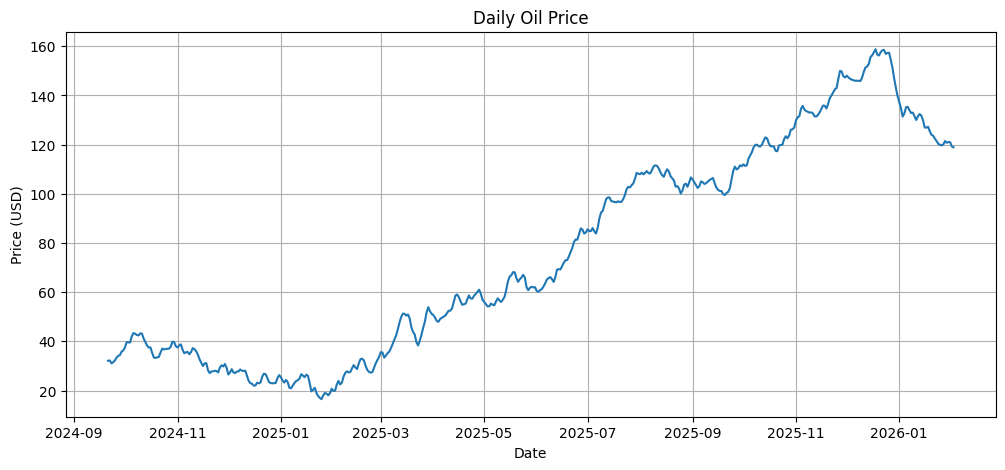

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['price'])
plt.title("Daily Oil Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

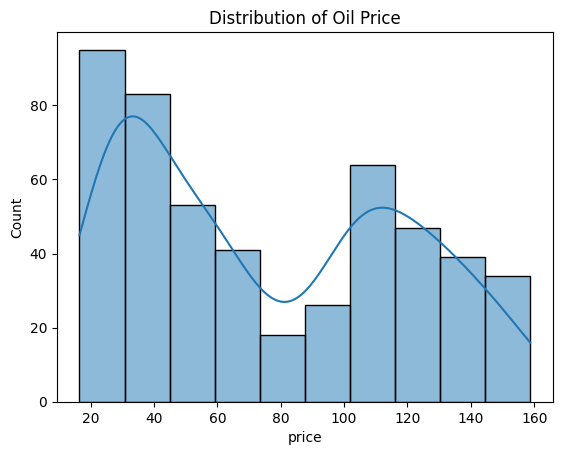

In [6]:
sns.histplot(df['price'], kde=True)
plt.title("Distribution of Oil Price")
plt.show()

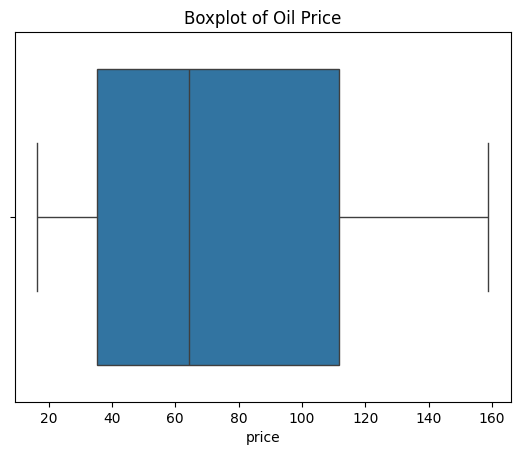

In [7]:
sns.boxplot(x=df['price'])
plt.title("Boxplot of Oil Price")
plt.show()

In [8]:
def adf_test(series, title=''):
    print(f'ADF Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF statistic','p-value','# lags used','# observations used']
    out = pd.Series(result[0:4], index=labels)
    for key, value in result[4].items():
        out[f'critical value ({key})'] = value
    print(out.to_string())
    if result[1] <= 0.05:
        print("=> Stationary (reject H0 of unit root)")
    else:
        print("=> Non-stationary (fail to reject H0)")

In [9]:
adf_test(df['price'], 'Original price series')

ADF Test: Original price series
ADF statistic            -0.546234
p-value                   0.882674
# lags used              17.000000
# observations used     482.000000
critical value (1%)      -3.443990
critical value (5%)      -2.867555
critical value (10%)     -2.569974
=> Non-stationary (fail to reject H0)


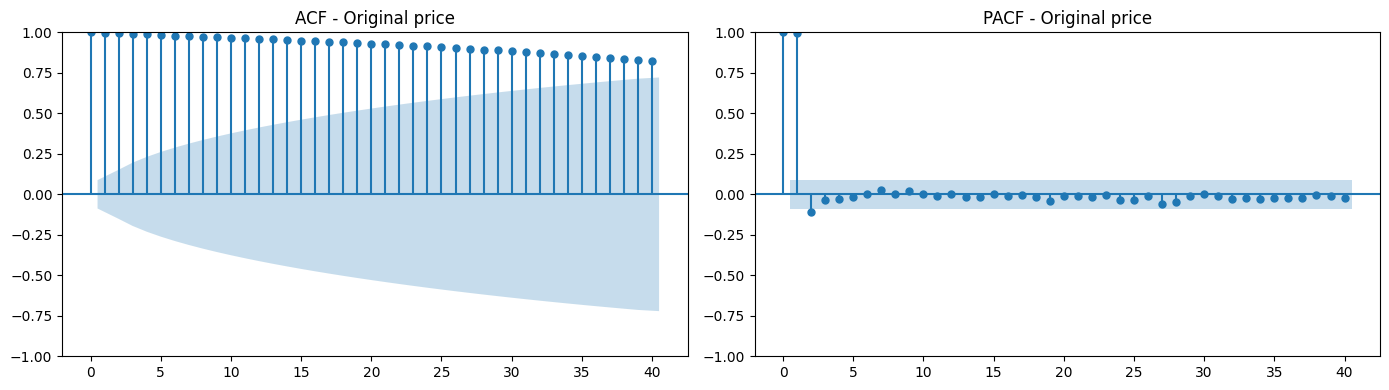

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['price'].dropna(), ax=axes[0], lags=40)
plot_pacf(df['price'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[0].set_title('ACF - Original price')
axes[1].set_title('PACF - Original price')
plt.tight_layout()
plt.show()

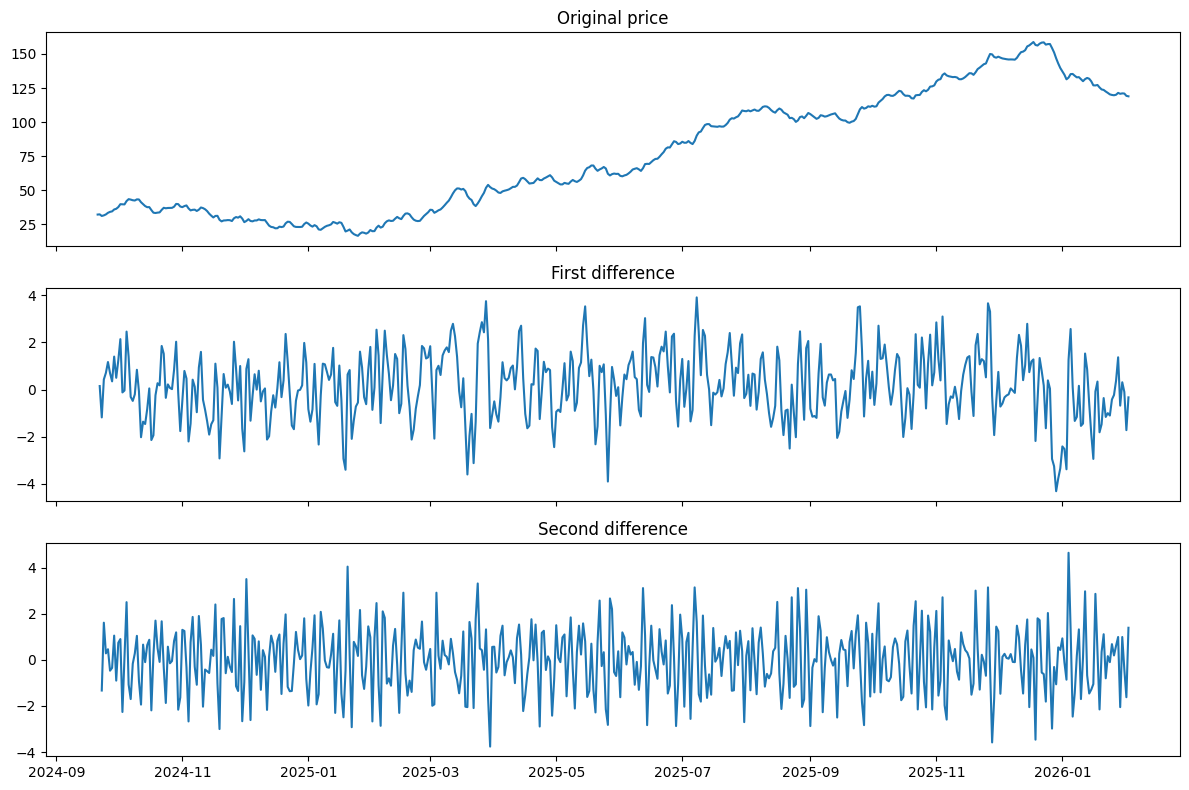

In [11]:
# First and second differences
df['price_diff1'] = df['price'].diff()
df['price_diff2'] = df['price_diff1'].diff()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['price']); axes[0].set_title("Original price")
axes[1].plot(df['price_diff1']); axes[1].set_title("First difference")
axes[2].plot(df['price_diff2']); axes[2].set_title("Second difference")
plt.tight_layout()
plt.show()

In [12]:
adf_test(df['price_diff1'], 'First difference')
adf_test(df['price_diff2'], 'Second difference')

ADF Test: First difference
ADF statistic            -4.541460
p-value                   0.000165
# lags used              16.000000
# observations used     482.000000
critical value (1%)      -3.443990
critical value (5%)      -2.867555
critical value (10%)     -2.569974
=> Stationary (reject H0 of unit root)
ADF Test: Second difference
ADF statistic          -9.004202e+00
p-value                 6.376639e-15
# lags used             1.700000e+01
# observations used     4.800000e+02
critical value (1%)    -3.444047e+00
critical value (5%)    -2.867580e+00
critical value (10%)   -2.569987e+00
=> Stationary (reject H0 of unit root)


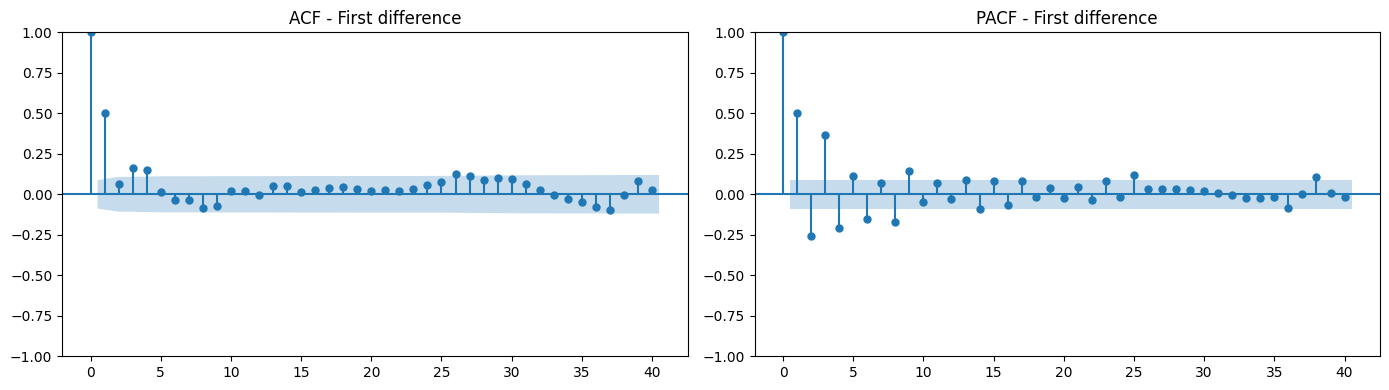

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['price_diff1'].dropna(), ax=axes[0], lags=40)
plot_pacf(df['price_diff1'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[0].set_title('ACF - First difference')
axes[1].set_title('PACF - First difference')
plt.tight_layout()
plt.show()

In [14]:
# Use the original price series
y = df['price'].astype(float)

# 80% train, 20% test split by time
train_size = int(len(y) * 0.8)
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train period:", y_train.index.min(), "to", y_train.index.max(), "(", len(y_train), "points )")
print("Test period :", y_test.index.min(), "to", y_test.index.max(), "(", len(y_test), "points )")

Train period: 2024-09-21 00:00:00 to 2025-10-25 00:00:00 ( 400 points )
Test period : 2025-10-26 00:00:00 to 2026-02-02 00:00:00 ( 100 points )


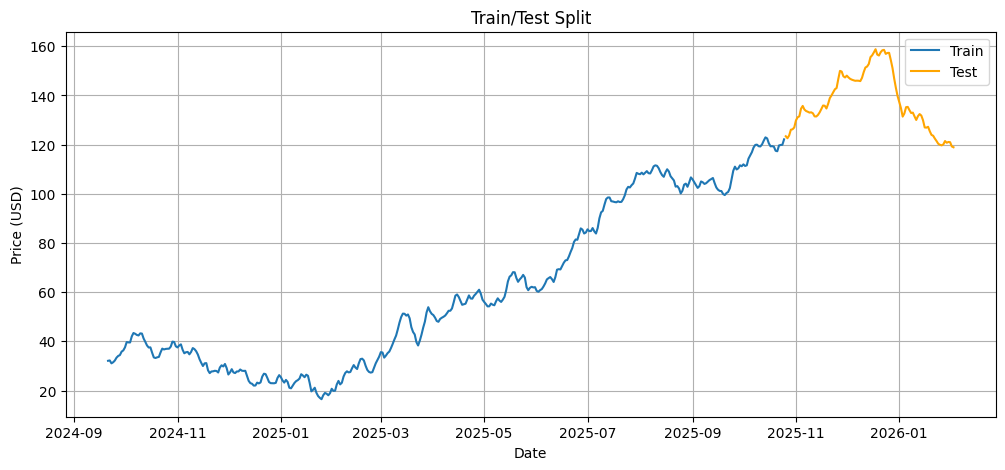

In [15]:
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.title("Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
warnings.filterwarnings("ignore")

p_values = range(0, 9)
d_values = range(0, 3)
q_values = range(0, 9)

best_aic = np.inf
best_order = None
best_model = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                model = ARIMA(y_train, order=order)
                model_fit = model.fit()
                aic = model_fit.aic
                if aic < best_aic:
                    best_aic = aic
                    best_order = order
                    best_model = model_fit
                    print(f"New best order {order} with AIC = {aic:.2f}")
            except Exception:
                # Some combinations will fail to converge; that's fine
                continue

print("\n=== Best ARIMA order ===")
print("Order (p,d,q):", best_order)
print("Best AIC:", best_aic)

New best order (0, 0, 0) with AIC = 3931.51
New best order (0, 0, 1) with AIC = 3387.63
New best order (0, 0, 2) with AIC = 2865.74
New best order (0, 0, 3) with AIC = 2456.51
New best order (0, 0, 4) with AIC = 2166.55
New best order (0, 0, 6) with AIC = 1910.62
New best order (0, 0, 7) with AIC = 1735.42
New best order (0, 1, 0) with AIC = 1387.88
New best order (0, 1, 1) with AIC = 1127.86
New best order (0, 1, 5) with AIC = 1127.79
New best order (0, 2, 2) with AIC = 1126.43
New best order (3, 1, 4) with AIC = 1125.58
New best order (8, 0, 0) with AIC = 258.18

=== Best ARIMA order ===
Order (p,d,q): (8, 0, 0)
Best AIC: 258.17842409922906


In [17]:
best_order = (3, 1, 4)

# Fit on training data
model_314 = ARIMA(y_train, order=best_order).fit()
print(model_314.summary())

# Forecast over test horizon
fc_314 = model_314.get_forecast(steps=len(y_test))
pred_314 = fc_314.predicted_mean
ci_314 = fc_314.conf_int(alpha=0.05)

pred_314.index = y_test.index
ci_314.index = y_test.index

rmse_314 = np.sqrt(mean_squared_error(y_test, pred_314))
print("\nTest RMSE for ARIMA", best_order, ":", rmse_314)

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  400
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -554.791
Date:                Fri, 06 Mar 2026   AIC                           1125.582
Time:                        13:05:51   BIC                           1157.494
Sample:                    09-21-2024   HQIC                          1138.221
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3355      0.071      4.746      0.000       0.197       0.474
ar.L2          0.2682      0.094      2.856      0.004       0.084       0.452
ar.L3         -0.8393      0.074    -11.360      0.0

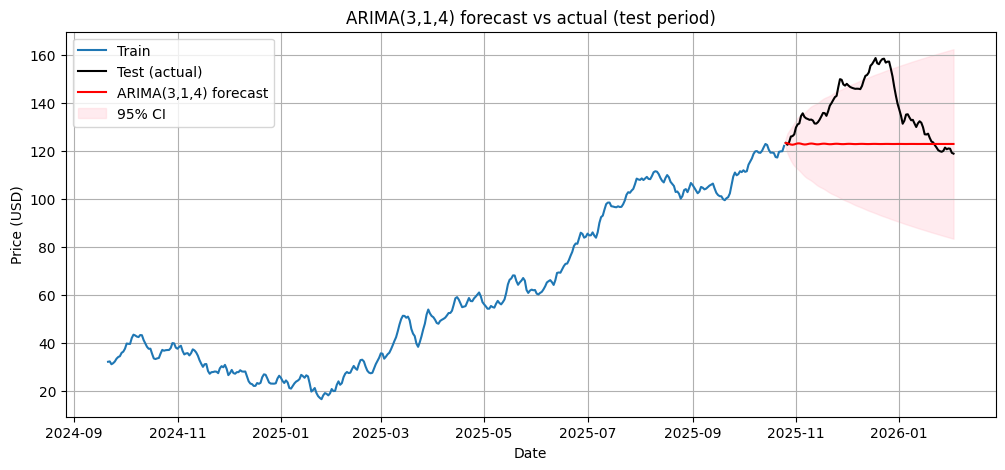

In [18]:
# Plot vs actual
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test (actual)', color='black')
plt.plot(pred_314.index, pred_314, label='ARIMA(3,1,4) forecast', color='red')
plt.fill_between(ci_314.index, ci_314.iloc[:,0], ci_314.iloc[:,1],
                 color='pink', alpha=0.3, label='95% CI')
plt.title("ARIMA(3,1,4) forecast vs actual (test period)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

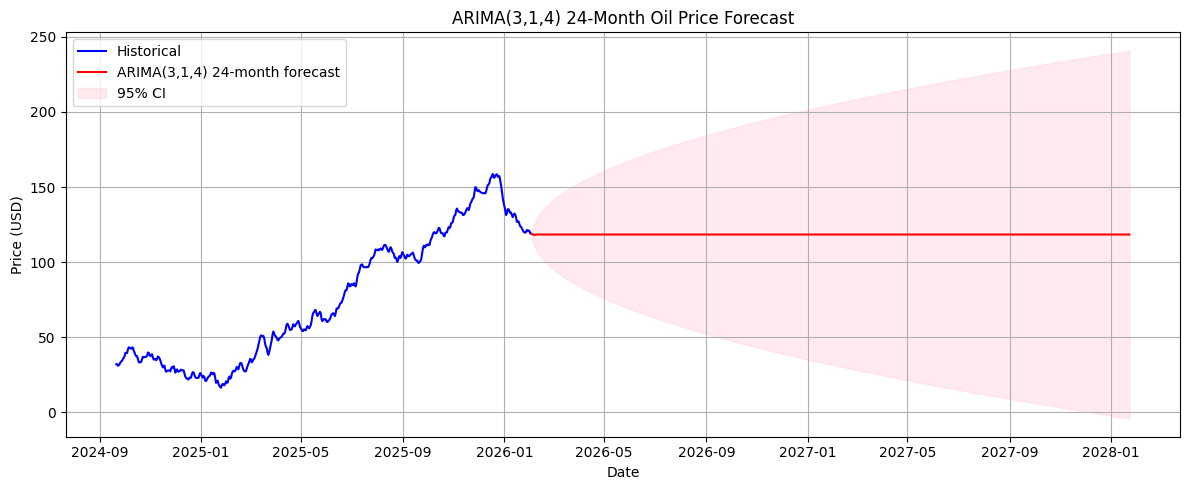

In [19]:
# Refit on full data
y_full = df['price'].astype(float)
final_314 = ARIMA(y_full, order=best_order).fit()

steps_24m = 24 * 30  # ~24 months
fc_24m_314 = final_314.get_forecast(steps=steps_24m)
fc_mean_314 = fc_24m_314.predicted_mean
fc_ci_314 = fc_24m_314.conf_int(alpha=0.05)

plt.figure(figsize=(12,5))
plt.plot(y_full.index, y_full, label='Historical', color='blue')
plt.plot(fc_mean_314.index, fc_mean_314, label='ARIMA(3,1,4) 24-month forecast', color='red')
plt.fill_between(fc_ci_314.index, fc_ci_314.iloc[:,0], fc_ci_314.iloc[:,1],
                 color='pink', alpha=0.3, label='95% CI')
plt.title("ARIMA(3,1,4) 24-Month Oil Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [25]:
# Use the full series for scaling
values = df['price'].astype(float).values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# Recreate train/test indices in scaled space
train_size = int(len(values_scaled) * 0.8)
train_scaled = values_scaled[:train_size]
test_scaled = values_scaled[train_size:]

def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, 0])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

window_size = 30

X_train, y_train_lstm = create_sequences(train_scaled, window_size=window_size)
X_test, y_test_lstm = create_sequences(test_scaled, window_size=window_size)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_train.shape, X_test.shape

((370, 30, 1), (70, 30, 1))

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Build a simple LSTM model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train_lstm,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0456 - val_loss: 0.0018
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 5.3520e-04
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.9809e-04 - val_loss: 6.5300e-04
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.6582e-04 - val_loss: 6.5865e-04
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.8528e-04 - val_loss: 5.0996e-04
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7490e-04 - val_loss: 7.4735e-04
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.2964e-04 - val_loss: 4.8621e-04
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.7342e-04 - val_loss: 5.1772e-04
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.1008e-04 - val_loss: 6.3904e-04
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.5749e-04 - val_loss: 6.0823e-04
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.4762e-04 - val_loss: 4.6219e

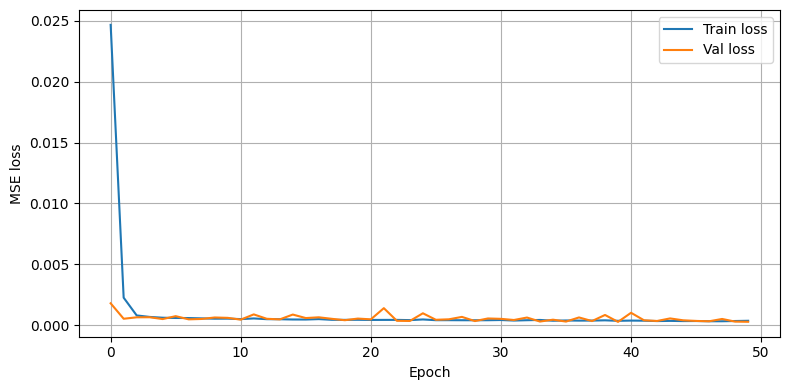

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
LSTM Test RMSE: 4.320724668999217


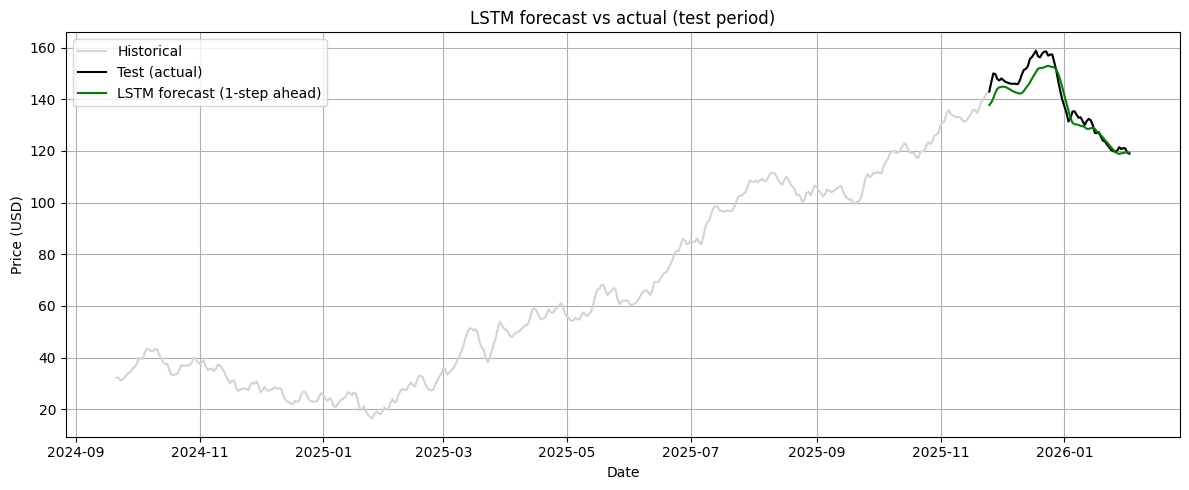

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Predict on test sequences (scaled)
y_pred_scaled = model.predict(X_test)

# Inverse-transform predictions and true values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# RMSE in original price units
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred))
print("LSTM Test RMSE:", rmse_lstm)

# Build corresponding date index for these points
start_idx = train_size + window_size
dates_lstm = df.index[start_idx:start_idx + len(y_pred)]

# Plot actual vs LSTM predictions over test region
plt.figure(figsize=(12,5))
plt.plot(df.index, df['price'], label='Historical', color='lightgray')
plt.plot(dates_lstm, y_true.flatten(), label='Test (actual)', color='black')
plt.plot(dates_lstm, y_pred.flatten(), label='LSTM forecast (1-step ahead)', color='green')
plt.title("LSTM forecast vs actual (test period)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Recreate sequences on the FULL scaled series for final model
X_all, y_all = create_sequences(values_scaled, window_size=window_size)
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

model_all = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

model_all.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_all = model_all.fit(
    X_all, y_all,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0798
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0037
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.3987e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3866e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.5557e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5385e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.6383e-04
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.6287e-04
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.6494e-04
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.5150e-04
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.2978e-04
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8890e-04
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5072e-04
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9403e-04
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━━━━━

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Steps: ~24 months of daily data
steps_24m = 24 * 30

# Start from the last window_size days of the FULL scaled series
last_window = values_scaled[-window_size:].reshape(1, window_size, 1)

future_scaled = []
current_window = last_window.copy()

for _ in range(steps_24m):
    next_pred = model_all.predict(current_window, verbose=0)[0, 0]
    future_scaled.append(next_pred)

    # slide the window
    current_window = np.append(current_window[:, 1:, :],
                               [[[next_pred]]], axis=1)

# Inverse-transform to original prices
future_scaled_arr = np.array(future_scaled).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_scaled_arr).flatten()

# Build future date index
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1),
                             periods=steps_24m, freq='D')

In [32]:
# Use previous 1-step-ahead residuals as error estimate
residuals_lstm = (y_true.flatten() - y_pred.flatten())
sigma = residuals_lstm.std()
print("Approx residual std:", sigma)

upper = future_prices + 1.96 * sigma
lower = np.maximum(future_prices - 1.96 * sigma, 0)  # clip at 0

Approx residual std: 3.4751040704020335


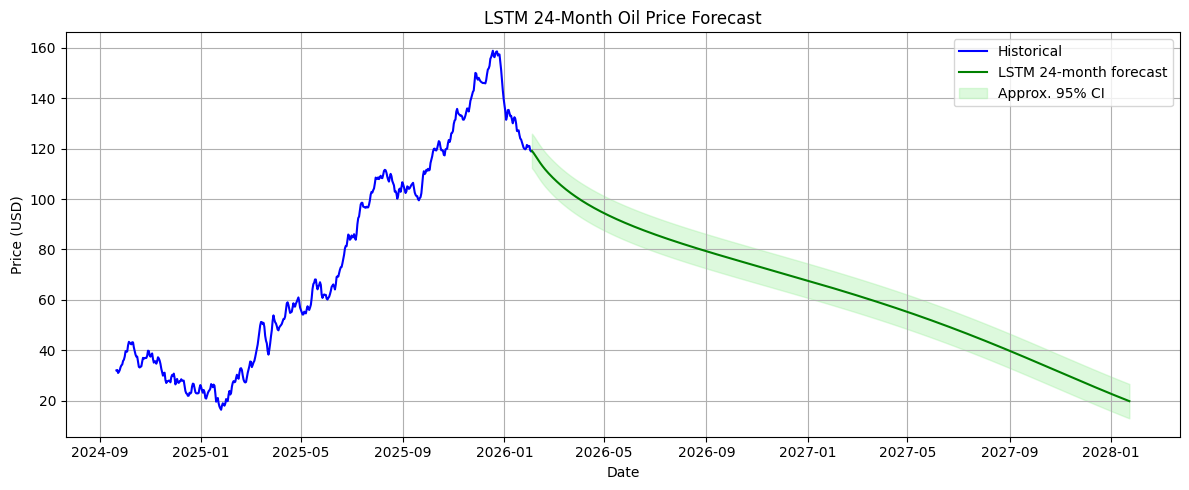

In [33]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['price'], label='Historical', color='blue')
plt.plot(future_dates, future_prices, label='LSTM 24-month forecast', color='green')

plt.fill_between(future_dates, lower, upper,
                 color='lightgreen', alpha=0.3, label='Approx. 95% CI')

plt.title("LSTM 24-Month Oil Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()